# Figure 6
Notebook will compare simulated cloud properties (at location of R\V Polarstern) for the background (1-13 April) and WAI (15-16 April) between the polluted and clean simulations. 

In [1]:
from glob import glob
import xarray as xr
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wrfpp
import string

## Read model output

In [2]:
apr = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,30,23,59))

simulations = {
    "ACI_OPT_2": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "ACI_OPT_2_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    }
}

wrfout = []
for sim,meta in simulations.items():
    ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=apr)
    ds_sim = ds_sim.expand_dims({
        "simulation": [sim]
    })
    ds_sim = ds_sim.assign_coords({
        "pollution_state": ("simulation",[meta["pollution_state"]]),
    })
    wrfout.append(ds_sim)
wrfout = xr.concat(wrfout, dim="simulation")
wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["altitude"] = wrfout.wrf.altitude_asl_c[:]
wrfout["box_depth"] = ((wrfout.wrf.altitude_asl[:]).rename({"bottom_top_stag":"bottom_top"})).diff("bottom_top")
wrfout["sfc_rad"] = (wrfout.SWDNB - wrfout.SWUPB + wrfout.LWDNB - wrfout.LWUPB).mean(["i","j"])
cdnc = 1e-6*(wrfout.QNCLOUD * wrfout.rho_air).where(wrfout.CLDFRA>0.1)/wrfout.CLDFRA
wrfout["cdnc"] = cdnc.where((wrfout.altitude>=0)*(wrfout.altitude<2000)).mean(["bottom_top","i","j"])
wrfout["clt_2km"] = 100*wrfout.CLDFRA.where((wrfout.altitude>=0)*(wrfout.altitude<2000)).max("bottom_top").mean(["i","j"])
wrfout["lwp"] = 1e3*wrfout.wrf.cloud_liquid_water_path[:].mean(["i","j"])
wrfout = wrfout[["lwp","sfc_rad","cdnc","clt_2km"]]


/tmp/ipykernel_1980/2804076302.py:16: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_1980/2804076302.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=a

## Process data into dataframe that plot function can read

In [34]:
bg = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,13,23,59))
wai = slice(dt.datetime(2020,4,15), dt.datetime(2020,4,16,23,59))

wai_state = []
for time in wrfout.Time.values:
    time = pd.Timestamp(time)
    if time>=bg.start and time<=bg.stop:
        wai_state.append("background")
    elif time>=wai.start and time<=wai.stop:
        wai_state.append("WAI")
    else:
        wai_state.append("unclassed")
wrfout = wrfout.assign_coords({
    "wai_state":("Time",wai_state),
})

plot_colours = {
    "polluted": "tab:red",
    "clean": "grey",
}

data = wrfout.sel(Time=wrfout.wai_state!="unclassed").to_dataframe()
medians = data.groupby(['wai_state','pollution_state']).median()
means = data.groupby(['wai_state','pollution_state']).mean()


## Make figure

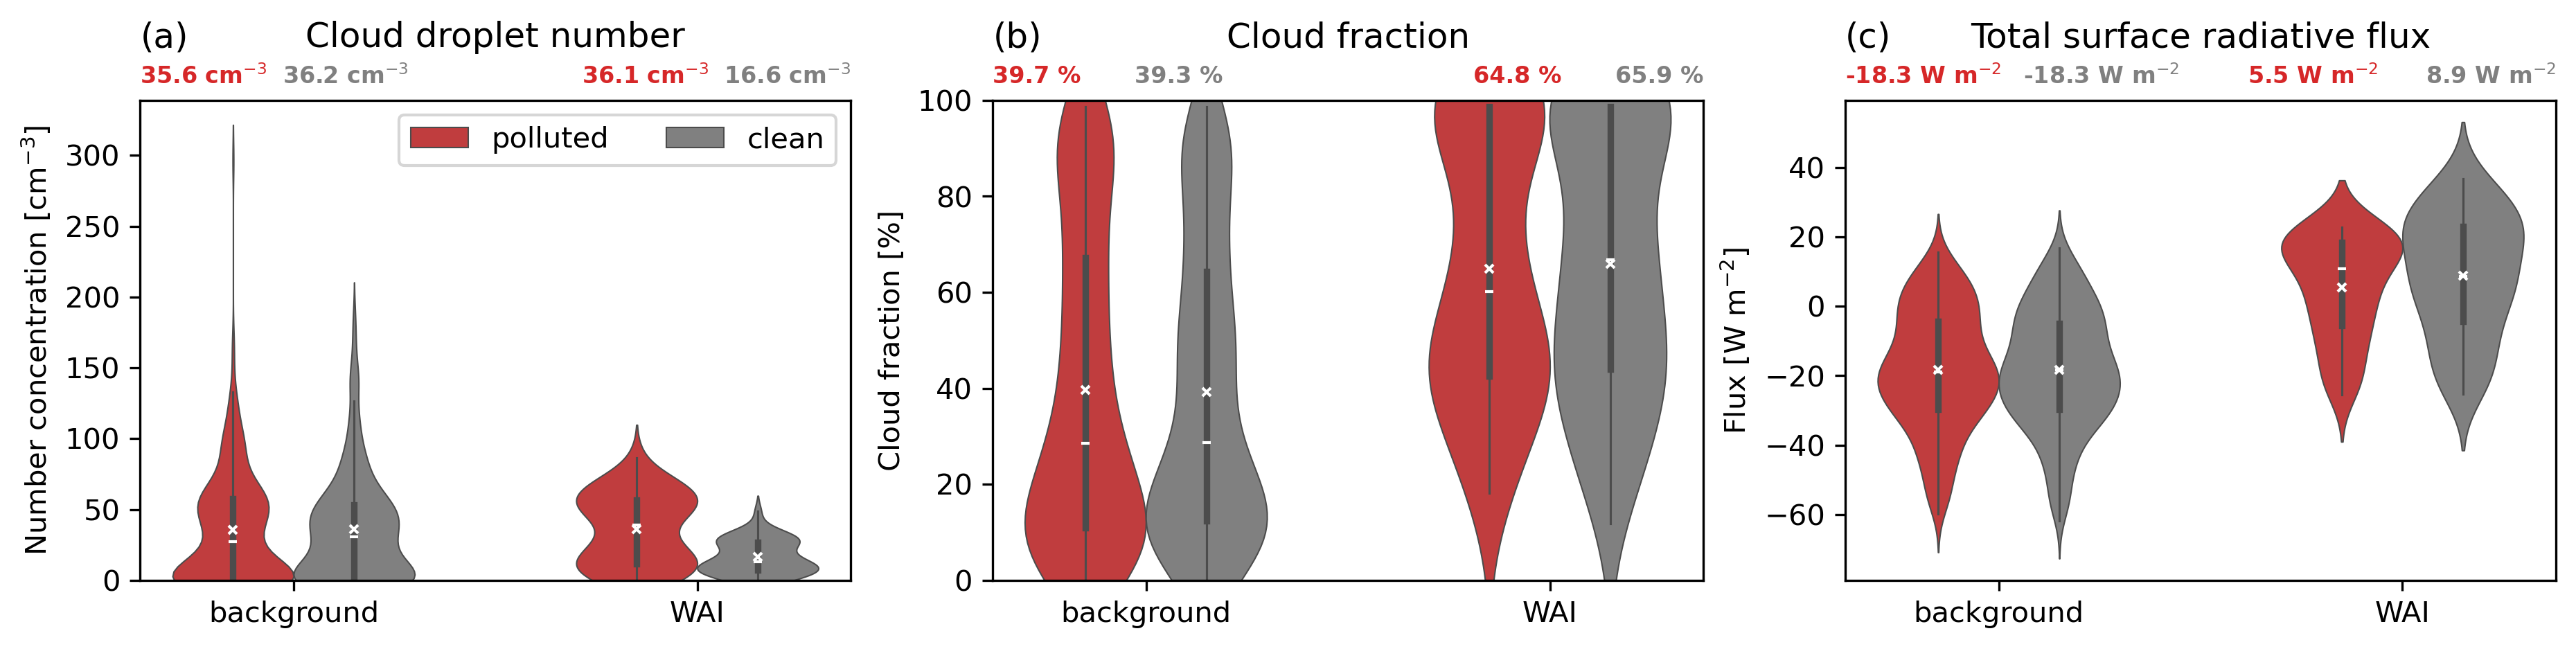

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15,3), dpi=300)

### CDNC

stats_cdnc = medians["cdnc"]
means_cdnc = means["cdnc"]
axes[0].text(
    s=f"{means_cdnc['background']['polluted']:.1f} cm$^{{-3}}$",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=8,
)
axes[0].text(
    s=f"{means_cdnc['background']['clean']:.1f} cm$^{{-3}}$",
    y=1.05, x=0.2, ha="left", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=8,
)
axes[0].text(
    s=f"{means_cdnc['WAI']['polluted']:.1f} cm$^{{-3}}$",
    y=1.05, x=0.8, ha="right", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=8,
)
axes[0].text(
    s=f"{means_cdnc['WAI']['clean']:.1f} cm$^{{-3}}$",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=8,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="cdnc",
    hue="pollution_state",
    ax=axes[0],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    palette=plot_colours,
)
axes[0].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        means_cdnc['background']['polluted'],
        means_cdnc['background']['clean'],
        means_cdnc['WAI']['polluted'],
        means_cdnc['WAI']['clean'],
    ],
    "wx",
    ms=3
)
axes[0].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        stats_cdnc['background']['polluted'],
        stats_cdnc['background']['clean'],
        stats_cdnc['WAI']['polluted'],
        stats_cdnc['WAI']['clean'],
    ],
    "w_",
    ms=3
)
axes[0].set_title("Cloud droplet number", y=1.075)
axes[0].set_ylabel("Number concentration [cm$^{{-3}}$]")
axes[0].set_xlabel("")
axes[0].set_ylim(bottom=0)

### CLOUD FRACTION

stats_cf = medians["clt_2km"]
means_cf = means["clt_2km"]
axes[1].text(
    s=f"{means_cf['background']['polluted']:.1f} %",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=8,
)
axes[1].text(
    s=f"{means_cf['background']['clean']:.1f} %",
    y=1.05, x=0.2, ha="left", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=8,
)
axes[1].text(
    s=f"{means_cf['WAI']['polluted']:.1f} %",
    y=1.05, x=0.8, ha="right", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=8,
)
axes[1].text(
    s=f"{means_cf['WAI']['clean']:.1f} %",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=8,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="clt_2km",
    hue="pollution_state",
    ax=axes[1],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    legend=False,
    palette=plot_colours,
)
axes[1].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        means_cf['background']['polluted'],
        means_cf['background']['clean'],
        means_cf['WAI']['polluted'],
        means_cf['WAI']['clean'],
    ],
    "wx",
    ms=3
)
axes[1].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        stats_cf['background']['polluted'],
        stats_cf['background']['clean'],
        stats_cf['WAI']['polluted'],
        stats_cf['WAI']['clean'],
    ],
    "w_",
    ms=3
)
axes[1].set_title("Cloud fraction", y=1.075)
axes[1].set_ylabel("Cloud fraction [%]")
axes[1].set_xlabel("")
axes[1].set_ylim(0,100)

### SURFACE RAD FLUX

stats_rad = medians["sfc_rad"]
means_rad = means["sfc_rad"]
axes[2].text(
    s=f"{means_rad['background']['polluted']:.1f} W m$^{{-2}}$",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=8,
)
axes[2].text(
    s=f"{means_rad['background']['clean']:.1f} W m$^{{-2}}$",
    y=1.05, x=0.25, ha="left", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=8,
)
axes[2].text(
    s=f"{means_rad['WAI']['polluted']:.1f} W m$^{{-2}}$",
    y=1.05, x=0.75, ha="right", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=8,
)
axes[2].text(
    s=f"{means_rad['WAI']['clean']:.1f} W m$^{{-2}}$",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=8,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="sfc_rad",
    hue="pollution_state",
    ax=axes[2],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    legend=False,
    palette=plot_colours,
)
axes[2].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        means_rad['background']['polluted'],
        means_rad['background']['clean'],
        means_rad['WAI']['polluted'],
        means_rad['WAI']['clean'],
    ],
    "wx",
    ms=3
)
axes[2].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        stats_rad['background']['polluted'],
        stats_rad['background']['clean'],
        stats_rad['WAI']['polluted'],
        stats_rad['WAI']['clean'],
    ],
    "w_",
    ms=3
)
axes[2].set_title("Total surface radiative flux", y=1.075)
axes[2].set_ylabel("Flux [W m$^{{-2}}$]")
axes[2].set_xlabel("")

axes[0].legend(ncols=2)
for i in range(len(axes)):
    axes[i].set_title(f"({string.ascii_lowercase[i]})", y=1.075, loc="left")
plt.savefig("../figures/figure6.png", bbox_inches="tight")

In [36]:
# print LWP stats
stats_lwp = medians["lwp"]
print("\nLWP medians:")
print(
    f"""bg polluted:  {stats_lwp['background']['polluted']:.1f} g m-2,
bg clean:     {stats_lwp['background']['clean']:.1f} g m-2,
WAI polluted: {stats_lwp['WAI']['polluted']:.1f} g m-2,
WAI clean:    {stats_lwp['WAI']['clean']:.1f} g m-2"""
)

stats_lwp = means["lwp"]
print("\nLWP means:")
print(
    f"""bg polluted:  {stats_lwp['background']['polluted']:.1f} g m-2,
bg clean:     {stats_lwp['background']['clean']:.1f} g m-2,
WAI polluted: {stats_lwp['WAI']['polluted']:.1f} g m-2,
WAI clean:    {stats_lwp['WAI']['clean']:.1f} g m-2"""
)

stats_cdnc = means["cdnc"]
print("\nCDNC means:")
print(
    f"""bg polluted:  {stats_cdnc['background']['polluted']:.1f} cm-3,
bg clean:     {stats_cdnc['background']['clean']:.1f} cm-3,
WAI polluted: {stats_cdnc['WAI']['polluted']:.1f} cm-3,
WAI clean:    {stats_cdnc['WAI']['clean']:.1f} cm-3"""
)

stats_rad = means["sfc_rad"]
print("\nFlux means:")
print(
    f"""bg polluted:  {stats_rad['background']['polluted']:.1f} W m-2,
bg clean:     {stats_rad['background']['clean']:.1f} W m-2,
WAI polluted: {stats_rad['WAI']['polluted']:.1f} W m-2,
WAI clean:    {stats_rad['WAI']['clean']:.1f} W m-2"""
)


LWP medians:
bg polluted:  0.7 g m-2,
bg clean:     0.8 g m-2,
WAI polluted: 30.4 g m-2,
WAI clean:    43.8 g m-2

LWP means:
bg polluted:  1.8 g m-2,
bg clean:     2.0 g m-2,
WAI polluted: 80.5 g m-2,
WAI clean:    53.1 g m-2

CDNC means:
bg polluted:  35.6 cm-3,
bg clean:     36.2 cm-3,
WAI polluted: 36.1 cm-3,
WAI clean:    16.6 cm-3

Flux means:
bg polluted:  -18.3 W m-2,
bg clean:     -18.3 W m-2,
WAI polluted: 5.5 W m-2,
WAI clean:    8.9 W m-2
